## Execute this if required
!pip install dotenv langchain langchain-core langchain-mistralai
## Also load MISTRAL_API_KEY from env

In [130]:
from IPython.display import display, HTML

display(HTML("""
<style>
.output_scroll {
    height: auto !important;
    max-height: none !important;
}
</style>
"""))

In [131]:
from dotenv import load_dotenv
load_dotenv()

from langchain_mistralai import ChatMistralAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI

In [132]:
def get_llm(
    model: str = "mistral-small-latest",
    temperature: float = 0.0,
    max_retries: int = 2,
):
    """
    Creates and returns an LLM instance.
    """
    return ChatMistralAI(
        model=model,
        temperature=temperature,
        max_retries=max_retries
    )
   

In [133]:
def build_evaluator_prompt():
    return ChatPromptTemplate.from_messages(
        [
            (
                "system",
                """
You are a strict but fair mathematics exam evaluator.

Input:
1. OCR-extracted student answer.
2. Correct reference answer.
3. Maximum marks.

Evaluation Rules:
- Evaluate ONLY what is clearly written.
- Do NOT assume missing content.
- Do NOT infer unstated reasoning.
- Students may skip trivial or obvious intermediate steps.
- Do NOT penalize for missing minor or routine steps if logical continuity is clear.
- Penalize only if a missing step causes incorrect logic or invalid reasoning.
- Award marks strictly for visible valid mathematical progress.
- Keep step descriptions very short.
- Be accurate when totaling marks.

If a major conceptual or numerical mistake exists, describe it briefly.
If none, return empty string.

Return STRICT JSON only:

{{
  "evaluation": [
    {{
      "step": "short step",
      "correct": true,
      "obtained_marks": number
    }}
  ],
  "total_obtained_marks": number,
  "total_marks": number,
  "critical_mistake": "brief description or empty string"
}}
"""
            ),
            (
                "human",
                """
OCR Answer:
{ocr_text}

Reference Answer:
{original_answer}

Maximum Marks: {max_marks}
"""
            ),
        ]
    )

In [134]:
def build_evaluator_prompt():
    return ChatPromptTemplate.from_messages(
        [
            (
                "system",
                """
You are a strict mathematics exam evaluator.

Input:
1. OCR student answer.
2. Correct reference answer.
3. Maximum marks.

Core Rules:
- Evaluate ONLY what is written.
- Do NOT assume missing steps.
- Do NOT infer unstated reasoning.
- Award marks strictly for visible valid steps.
- Keep step descriptions very short.
- Total marks must be exact.

Working Requirement Policy (MANDATORY):

1. If the reference solution clearly requires multiple steps 
   (e.g., use of identities, logarithm laws, algebraic rearrangement,
   substitution, integration steps, derivations),

   AND the student provides ONLY a final answer without meaningful steps,

   THEN:
   - Award 0 marks.
   - Set evaluation as empty list.
   - Do not give 1 marks for that step also award 0 mark onlyyy.
   - Set critical_mistake = "No working shown for multi-step problem".

2. If the problem is naturally single-step 
   (simple evaluation or direct known value),
   then direct answer is acceptable.

3. Do NOT guess copying.
   Only judge based on presence or absence of required working.

If a major conceptual or numerical mistake exists,
describe it briefly. Otherwise return empty string.

Return STRICT JSON only:

{{
  "evaluation": [
    {{
      "step": "short step",
      "correct": true,
      "obtained_marks": number
    }}
  ],
  "total_obtained_marks": number,
  "total_marks": number,
  "critical_mistake": "brief description or empty string"
}}
"""
            ),
            (
                "human",
                """
OCR Answer:
{ocr_text}

Reference Answer:
{original_answer}

Maximum Marks: {max_marks}
"""
            ),
        ]
    )

In [ ]:
def evaluate_answer(
    ocr_text: str,
    original_answer: str,
    max_marks: int,
    llm=None
):
    """
    Evaluates a student's OCR answer and returns STRICT JSON output.
    """

    if llm is None:
        llm = get_llm()

    prompt = build_evaluator_prompt()
    chain = prompt | llm

    response = chain.invoke(
        {
            "ocr_text": ocr_text,
            "original_answer": original_answer,
            "max_marks": max_marks
        }
    )

    return response.content

In [136]:
llm = get_llm()

### Test Problem 1

Displaying PDF pages as images:


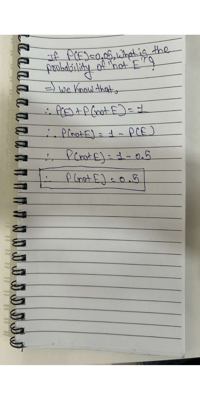

In [137]:
from pdf2image import convert_from_path
from IPython.display import display
print("Displaying PDF pages as images:")

pages = convert_from_path("probability_1.pdf")

for page in pages:
    resized = page.resize((200, 400))  # width, height in pixels
    display(resized)

In [159]:
ocr_text = r"""
If $P(E)=0.05$, what is the probability of "not $E$ "?
⇒ we know that,
$$
\begin{aligned}
& \therefore P(E)+P(\text { not } E)=1 \\
& \therefore P(\text { not } E)=1-P(E) \\
& \therefore P(\text { not } E)=1-0.5 \\
& \therefore P(\text { not } E)=0.5
\end{aligned}
$$
"""

original_answer = r"""
{
          "question_no": 1,
          "question_text": "If $P(E) = 0.05$, what is the probability of 'not E'?",
          "topic": "Probability",
          "standard": 10,
          "max_marks": null,
          "AI_generated_answer": "Step 1: The probability of 'not E' is given by 1 - P(E)\nStep 2: Given P(E) = 0.05\nStep 3: Calculate 1 - 0.05 = 0.95\nFinal Answer: 0.95"
        },
"""
max_marks = 10

result = evaluate_answer(
    ocr_text=ocr_text,
    original_answer=original_answer,
    max_marks=max_marks,
    llm = llm,
)

print(result)

Raw LLM Response:
content='```json\n{\n  "evaluation": [\n    {\n      "step": "Step 1: The probability of \'not E\' is given by 1 - P(E)",\n      "correct": true,\n      "obtained_marks": 2\n    },\n    {\n      "step": "Step 2: Given P(E) = 0.05",\n      "correct": true,\n      "obtained_marks": 2\n    },\n    {\n      "step": "Step 3: Calculate 1 - 0.05 = 0.95",\n      "correct": false,\n      "obtained_marks": 0\n    },\n    {\n      "step": "Final Answer: 0.95",\n      "correct": false,\n      "obtained_marks": 0\n    }\n  ],\n  "total_obtained_marks": 4,\n  "total_marks": 10,\n  "critical_mistake": "Incorrect calculation in step 3"\n}\n```' additional_kwargs={} response_metadata={'token_usage': {'prompt_tokens': 598, 'total_tokens': 814, 'completion_tokens': 216, 'prompt_tokens_details': {'cached_tokens': 0}}, 'model_name': 'mistral-small-latest', 'model': 'mistral-small-latest', 'finish_reason': 'stop', 'model_provider': 'mistralai'} id='lc_run--019c7ae6-f831-7370-925f-badf1508e

### Test problem 2

Displaying PDF pages as images:


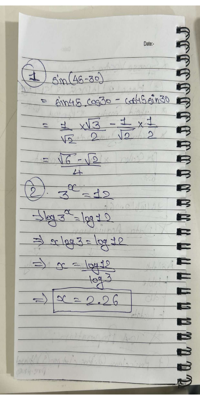

In [139]:
print("Displaying PDF pages as images:")
pages = convert_from_path("two-questions.pdf")

for page in pages:
    resized = page.resize((200, 400))  # width, height in pixels
    display(resized)

In [140]:
ocr_text = r"""
$1 \sin (45-30)$
$$
\begin{aligned}
& =\sin 45 \cdot \cos 30-\cos 45 \sin 30 \\
& =\frac{1}{\sqrt{2}} \times \frac{\sqrt{3}}{2}-\frac{1}{\sqrt{2}} \times \frac{1}{2} \\
& =\frac{\sqrt{6}-\sqrt{2}}{4}
\end{aligned}
$$
"""

original_answer = r"""
  {
          "question_no": 2,
          "question_text": "What is the value of $\\sin(45 - 30)$?",
          "topic": "Trigonometry",
          "standard": 10,
          "max_marks": null,
          "AI_generated_answer": "Step 1: Use the sine subtraction formula: $\\sin(a - b) = \\sin a \\cos b - \\cos a \\sin b$\nStep 2: Here, a = 45° and b = 30°\nStep 3: Substitute values: $\\sin(45 - 30) = \\sin 45° \\cos 30° - \\cos 45° \\sin 30°$\nStep 4: Use known values: $\\sin 45° = \\frac{\\sqrt{2}}{2}$, $\\cos 30° = \\frac{\\sqrt{3}}{2}$, $\\cos 45° = \\frac{\\sqrt{2}}{2}$, $\\sin 30° = \\frac{1}{2}$\nStep 5: Calculate: $\\sin(45 - 30) = \\frac{\\sqrt{2}}{2} \\cdot \\frac{\\sqrt{3}}{2} - \\frac{\\sqrt{2}}{2} \\cdot \\frac{1}{2}$\nStep 6: Simplify: $\\sin(45 - 30) = \\frac{\\sqrt{6}}{4} - \\frac{\\sqrt{2}}{4}$\nStep 7: Combine terms: $\\sin(45 - 30) = \\frac{\\sqrt{6} - \\sqrt{2}}{4}$\nFinal Answer: $\\frac{\\sqrt{6} - \\sqrt{2}}{4}$"
        },
"""

max_marks = 10

result = evaluate_answer(
    ocr_text=ocr_text,
    original_answer=original_answer,
    max_marks=max_marks
)

print(result)

```json
{
  "evaluation": [
    {
      "step": "Use sine subtraction formula",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Substitute values correctly",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Use known trigonometric values",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Calculate the expression",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Simplify the expression",
      "correct": true,
      "obtained_marks": 2
    }
  ],
  "total_obtained_marks": 10,
  "total_marks": 10,
  "critical_mistake": ""
}
```


#### problem-2 TEST-CASES

In [141]:
ocr_wrong_sign = r"""
$1 \sin (45-30)$
$$
\begin{aligned}
& =\sin 45 \cdot \cos 30+\cos 45 \sin 30 \\
& =\frac{1}{\sqrt{2}} \times \frac{\sqrt{3}}{2}+\frac{1}{\sqrt{2}} \times \frac{1}{2} \\
& =\frac{\sqrt{6}+\sqrt{2}}{4}
\end{aligned}
$$
"""

ocr_wrong_sign = r"""
$1 \sin (45-30)$
$$
\begin{aligned}
& =\sin 45 \cdot \cos 30+\cos 45 \sin 30 \\
& =\frac{1}{\sqrt{2}} \times \frac{\sqrt{3}}{2}+\frac{1}{\sqrt{2}} \times \frac{1}{2} \\
& =\frac{\sqrt{6}+\sqrt{2}}{4}
\end{aligned}
$$
"""

ocr_wrong_value = r"""
$1 \sin (45-30)$
$$
\begin{aligned}
& =\sin 45 \cdot \cos 30-\cos 45 \sin 30 \\
& =\frac{1}{\sqrt{2}} \times \frac{1}{2}-\frac{1}{\sqrt{2}} \times \frac{1}{2} \\
& =0
\end{aligned}
$$
"""
ocr_skip_step = r"""
$1 \sin (45-30)$
$$
\begin{aligned}
& =\frac{\sqrt{2}}{2}\cdot\frac{\sqrt{3}}{2}-\frac{\sqrt{2}}{2}\cdot\frac{1}{2} \\
& =\frac{\sqrt{6}-\sqrt{2}}{4}
\end{aligned}
$$
"""
ocr_wrong_simplify = r"""
$1 \sin (45-30)$
$$
\begin{aligned}
& =\sin 45 \cdot \cos 30-\cos 45 \sin 30 \\
& =\frac{1}{\sqrt{2}} \times \frac{\sqrt{3}}{2}-\frac{1}{\sqrt{2}} \times \frac{1}{2} \\
& =\frac{\sqrt{6}-\sqrt{2}}{2}
\end{aligned}
$$
"""

In [142]:
def test_ocr_variations(original_answer, max_marks):

    test_cases = [
        {
            "name": "Correct Answer",
            "description": "Original correct derivation.",
            "ocr": ocr_text
        },
        {
            "name": "Wrong Formula Sign",
            "description": "Used '+' instead of '-' in sine subtraction identity.",
            "ocr": ocr_wrong_sign
        },
        {
            "name": "Wrong Trig Value",
            "description": "Used incorrect value for cos 30.",
            "ocr": ocr_wrong_value
        },
        {
            "name": "Skipped Identity Step",
            "description": "Did not explicitly write sine subtraction formula.",
            "ocr": ocr_skip_step
        },
        {
            "name": "Wrong Simplification",
            "description": "Made arithmetic mistake in final simplification.",
            "ocr": ocr_wrong_simplify
        },
    ]

    for case in test_cases:
        print("\n" + "="*60)
        print(f"Test Case: {case['name']}")
        print(f"Change Description: {case['description']}")
        print("="*60)

        result = evaluate_answer(
            ocr_text=case["ocr"],
            original_answer=original_answer,
            max_marks=max_marks
        )

        print(result)

| Case                 | Should Award      |
| -------------------- | ----------------- |
| Correct              | Full marks        |
| Wrong Sign           | Major penalty     |
| Wrong Value          | Major penalty     |
| Skipped Step         | No penalty        |
| Wrong Simplification | Partial deduction |


In [143]:
test_ocr_variations(original_answer, 10)


Test Case: Correct Answer
Change Description: Original correct derivation.
```json
{
  "evaluation": [
    {
      "step": "Use sine subtraction formula",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Substitute values correctly",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Use known trigonometric values",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Calculate the expression",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Simplify the expression",
      "correct": true,
      "obtained_marks": 2
    }
  ],
  "total_obtained_marks": 10,
  "total_marks": 10,
  "critical_mistake": ""
}
```

Test Case: Wrong Formula Sign
Change Description: Used '+' instead of '-' in sine subtraction identity.
```json
{
  "evaluation": [
    {
      "step": "Apply sine subtraction formula",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Substitute val

### Test Problem 3

In [144]:
ocr_text = r"""
(2) $3^{x}=12$
$$
\begin{aligned}
& \Rightarrow \log 3^{x}=\log 12 \\
& \Rightarrow x \log 3=\log 12 \\
& \Rightarrow x=\frac{\log 12}{\log 3} \\
& \Rightarrow x=2.26
\end{aligned}
$$
"""

original_answer = r"""
{
          "question_no": 3,
          "question_text": "in $3^x = 12$, What is the value of $x$?",
          "topic": "Algebra",
          "standard": 10,
          "max_marks": null,
          "AI_generated_answer": "Step 1: Given equation: $3^x = 12$\nStep 2: Take logarithm (base 10) on both sides: $\\log(3^x) = \\log(12)$\nStep 3: Use logarithm power rule: $x \\log 3 = \\log 12$\nStep 4: Solve for x: $x = \\frac{\\log 12}{\\log 3}$\nStep 5: Calculate using a calculator: $x \\approx \\frac{1.079}{0.477} \\approx 2.26$\nFinal Answer: $x \\approx 2.26$"
        },
"""

max_marks = 10

result = evaluate_answer(
    ocr_text=ocr_text,
    original_answer=original_answer,
    max_marks=max_marks
)

print(result)

```json
{
  "evaluation": [
    {
      "step": "Take logarithm on both sides",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Apply logarithm power rule",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Solve for x",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Calculate using a calculator",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Final Answer",
      "correct": true,
      "obtained_marks": 2
    }
  ],
  "total_obtained_marks": 10,
  "total_marks": 10,
  "critical_mistake": ""
}
```


#### Problem-3 TEST-CASES

In [145]:
original_ocr_log = r"""
(2) $3^{x}=12$
$$
\begin{aligned}
& \Rightarrow \log 3^{x}=\log 12 \\
& \Rightarrow x \log 3=\log 12 \\
& \Rightarrow x=\frac{\log 12}{\log 3} \\
& \Rightarrow x=2.26
\end{aligned}
$$
"""
ocr_skip_power_rule = r"""
(2) $3^{x}=12$
$$
\begin{aligned}
& \Rightarrow \log 3^{x}=\log 12 \\
& \Rightarrow x=\frac{\log 12}{\log 3} \\
& \Rightarrow x=2.26
\end{aligned}
$$
"""
ocr_wrong_log_rule = r"""
(2) $3^{x}=12$
$$
\begin{aligned}
& \Rightarrow \log 3^{x}=\log 12 \\
& \Rightarrow \log 3 + \log x=\log 12 \\
& \Rightarrow x=2.26
\end{aligned}
$$
"""
ocr_wrong_rearrange = r"""
(2) $3^{x}=12$
$$
\begin{aligned}
& \Rightarrow \log 3^{x}=\log 12 \\
& \Rightarrow x \log 3=\log 12 \\
& \Rightarrow x=\log 12 \times \log 3 \\
& \Rightarrow x=0.51
\end{aligned}
$$
"""

ocr_wrong_numeric = r"""
(2) $3^{x}=12$
$$
\begin{aligned}
& \Rightarrow \log 3^{x}=\log 12 \\
& \Rightarrow x \log 3=\log 12 \\
& \Rightarrow x=\frac{\log 12}{\log 3} \\
& \Rightarrow x=2.10
\end{aligned}
$$
"""

ocr_only_final = r"""
(2) $3^{x}=12$

$$
x = 2.26
$$
"""

In [146]:
def test_log_variations(original_answer, max_marks):

    test_cases = [
        {
            "name": "Correct Solution",
            "description": "Complete and correct derivation.",
            "ocr": original_ocr_log
        },
        {
            "name": "Skipped Power Rule Step",
            "description": "Did not explicitly write x log 3 = log 12.",
            "ocr": ocr_skip_power_rule
        },
        {
            "name": "Wrong Log Rule",
            "description": "Used incorrect logarithm identity.",
            "ocr": ocr_wrong_log_rule
        },
        {
            "name": "Wrong Rearrangement",
            "description": "Multiplied instead of dividing by log 3.",
            "ocr": ocr_wrong_rearrange
        },
        {
            "name": "Wrong Final Approximation",
            "description": "Correct method but numerical calculator mistake.",
            "ocr": ocr_wrong_numeric
        },
        {
            "name": "Only Final Answer",
            "description": "No steps shown, only final value.",
            "ocr": ocr_only_final
        },
    ]

    for case in test_cases:
        print("\n" + "="*60)
        print(f"Test Case: {case['name']}")
        print(f"Change Description: {case['description']}")
        print("="*60)

        result = evaluate_answer(
            ocr_text=case["ocr"],
            original_answer=original_answer,
            max_marks=max_marks
        )

        print(result)

| Case                | Expected Behavior |
| ------------------- | ----------------- |
| Correct             | Full marks        |
| Skip Power Rule     | No penalty        |
| Wrong Log Rule      | Major deduction   |
| Wrong Rearrangement | Major deduction   |
| Wrong Numeric       | Partial deduction |
| Only Final          | Partial credit    |


In [147]:
test_log_variations(original_answer, 10)


Test Case: Correct Solution
Change Description: Complete and correct derivation.
```json
{
  "evaluation": [
    {
      "step": "Take logarithm on both sides",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Apply logarithm power rule",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Solve for x",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Calculate using a calculator",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Final Answer",
      "correct": true,
      "obtained_marks": 2
    }
  ],
  "total_obtained_marks": 10,
  "total_marks": 10,
  "critical_mistake": ""
}
```

Test Case: Skipped Power Rule Step
Change Description: Did not explicitly write x log 3 = log 12.
```json
{
  "evaluation": [
    {
      "step": "Take logarithm on both sides",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Apply logarithm power rule",
      "correct

Displaying PDF pages as images:


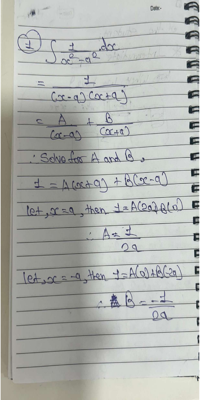

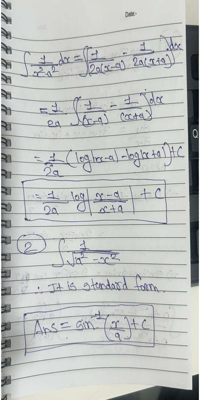

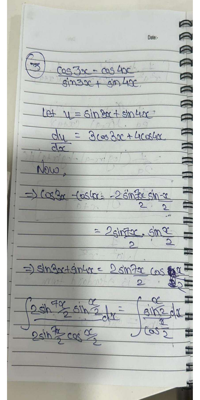

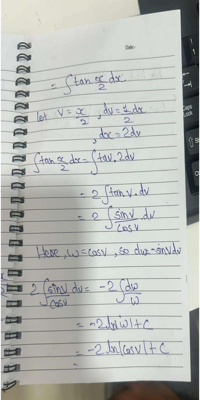

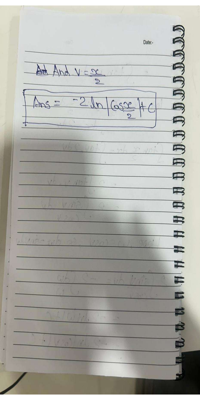

In [148]:
from pdf2image import convert_from_path
from IPython.display import display


print("Displaying PDF pages as images:")
pages = convert_from_path("11.pdf")

for page in pages:
    resized = page.resize((200, 400))  # width, height in pixels
    display(resized)

### Test Problem 4

In [149]:
ocr_text = r"""
(1) $\int \frac{1}{x^{2}-a^{2}} \cdot d x$
$$
\begin{aligned}
& =\frac{1}{(x-a)(x+a)} \\
& =\frac{A}{(x-a)}+\frac{B}{(x+a)}
\end{aligned}
$$
∴ Solve for $A$ and $B$,
$$
1=A(x+a)+B(x-a)
$$
let, $x=a$, then $1=A(2 a) B(0)$
$$
\therefore A=\frac{1}{2 a}
$$
let, $x=-a$, then $y=A(0)+B(-2 a)$
$$
\therefore B=\frac{-1}{2 a}
$$
$$
\begin{aligned}
& \int \frac{1}{x^{2}-a^{2}} d x=\int\left[\frac{1}{2 a(x-a)}-\frac{1}{2 a(x+a)}\right] d x \\
&=\frac{1}{2 a} \int\left(\frac{1}{(x-a)}-\frac{1}{(x+a)}\right) d x
\end{aligned}
$$
"""

original_answer = r"""
 {
          "question_no": 1,
          "question_text": "Evaluate the integral: $\\int {\frac {1}{x^{2}-a^{2}}}\\,dx$",
          "topic": "Calculus",
          "standard": null,
          "max_marks": null,
          "AI_generated_answer": "Step 1: Recognize the integral as a standard form related to partial fractions.\nStep 2: Decompose the integrand: $\frac{1}{x^2 - a^2} = \frac{1}{(x-a)(x+a)} = \frac{A}{x-a} + \frac{B}{x+a}$\nStep 3: Solve for A and B: $A = \frac{1}{2a}, B = -\frac{1}{2a}$\nStep 4: Rewrite the integral: $\\int \\left( \frac{1}{2a} \\cdot \frac{1}{x-a} - \frac{1}{2a} \\cdot \frac{1}{x+a} \right) dx$\nStep 5: Integrate term by term: $\frac{1}{2a} \\ln|x-a| - \frac{1}{2a} \\ln|x+a| + C$\nStep 6: Combine logarithms: $\frac{1}{2a} \\ln \\left| \frac{x-a}{x+a} \right| + C$\nFinal Answer: $\frac{1}{2a} \\ln \\left| \frac{x-a}{x+a} \right| + C$"
        },
"""

max_marks = 10

result = evaluate_answer(
    ocr_text=ocr_text,
    original_answer=original_answer,
    max_marks=max_marks
)

print(result)

```json
{
  "evaluation": [
    {
      "step": "Partial fraction decomposition setup",
      "correct": true,
      "obtained_marks": 1
    },
    {
      "step": "Solving for A and B",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Rewriting the integral",
      "correct": true,
      "obtained_marks": 1
    },
    {
      "step": "Integrating term by term",
      "correct": false,
      "obtained_marks": 0
    },
    {
      "step": "Combining logarithms",
      "correct": false,
      "obtained_marks": 0
    }
  ],
  "total_obtained_marks": 4,
  "total_marks": 10,
  "critical_mistake": "No final integration and combination of logarithms"
}
```


### Test Problem 5

In [150]:
ocr_text = r"""
(3) $\frac{\cos 3 x-\cos 4 x}{\sin 3 x+\sin 4 x}$
 
Let $y=\sin 3 x+\sin 4 x$
$$
\frac{d u}{d x}=3 \cos 3 x+4 \cos 4 x
$$
 
Now,
$$
\begin{aligned}
\Rightarrow \cos 3 x-\cos 4 x & =-2 \sin \frac{7 x}{2} \sin \frac{-x}{2} \\
& =2 \sin \frac{7 x}{2} \cdot \sin \frac{x}{2}
\end{aligned}
$$
$$
\begin{aligned}
& \Rightarrow \sin 3 x+\sin 4 x=2 \sin \frac{7 x}{2} \cos \frac{x}{2} \\
& \int \frac{2 \sin 7 x}{2} \sin \frac{x}{2} \\
& 2 \sin \frac{7 x}{2} \cos \frac{x}{2}
\end{aligned}=\int \frac{\sin \frac{x}{2}}{\cos \frac{x}{2}} d x
$$
$$
=\int \tan \frac{x}{2} d x .
$$
 
Let $v=\frac{x}{2}, d v=\frac{1}{2} d x$
$$
\begin{aligned}
& \int d x=2 d v \\
& \int \tan \frac{x}{2} d x=\int \operatorname{tav} \cdot 2 d v \\
&= 2 \int \tan v \cdot d v \\
&= 2 \int \frac{\sin v}{\cos v} \cdot d v
\end{aligned}
$$
 
Here, $\omega=\cos v$, so dur-sinvdv
$$
\begin{aligned}
2 \int \frac{\sin v}{\cos v} d v & =-2 \int \frac{d \omega}{\omega} \\
& =-2 \ln |\omega|+c \\
& =-2 \ln |\cos v|+c
\end{aligned}
$$
 
And $v=\frac{x}{2}$
Ans $=-2 \ln \left|\cos \frac{x}{2}\right|+c$
"""

original_answer = r"""
   {
          "question_no": 3,
          "question_text": "Evaluate the integral: $\\int {\frac {\\cos 3x-\\cos 4x}{\\sin 3x+\\sin 4x}}\\,dx$",
          "topic": "Calculus",
          "standard": null,
          "max_marks": null,
          "AI_generated_answer": "Step 1: Use the sum-to-product identities: $\\cos 3x - \\cos 4x = -2 \\sin \\left( \frac{7x}{2} \right) \\sin \\left( \frac{x}{2} \right)$ and $\\sin 3x + \\sin 4x = 2 \\sin \\left( \frac{7x}{2} \right) \\cos \\left( \frac{x}{2} \right)$\nStep 2: Simplify the integrand: $\frac{-2 \\sin \\left( \frac{7x}{2} \right) \\sin \\left( \frac{x}{2} \right)}{2 \\sin \\left( \frac{7x}{2} \right) \\cos \\left( \frac{x}{2} \right)} = -\tan \\left( \frac{x}{2} \right)$\nStep 3: Integrate: $-\\int \tan \\left( \frac{x}{2} \right) dx$\nStep 4: Use substitution: $u = \frac{x}{2}, du = \frac{1}{2} dx$\nStep 5: Rewrite the integral: $-2 \\int \tan(u) du = -2 \\ln|\\sec(u)| + C$\nStep 6: Substitute back: $u = \frac{x}{2}$\nFinal Answer: $-2 \\ln \\left| \\sec \\left( \frac{x}{2} \right) \right| + C$"
        }
"""

max_marks = 10

result = evaluate_answer(
    ocr_text=ocr_text,
    original_answer=original_answer,
    max_marks=max_marks
)

print(result)

```json
{
  "evaluation": [
    {
      "step": "Apply sum-to-product identities",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Simplify the integrand",
      "correct": false,
      "obtained_marks": 0
    },
    {
      "step": "Set up the integral with substitution",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Perform substitution correctly",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Integrate tan(u)",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Substitute back correctly",
      "correct": false,
      "obtained_marks": 0
    }
  ],
  "total_obtained_marks": 8,
  "total_marks": 10,
  "critical_mistake": "Incorrect simplification of the integrand and substitution back"
}
```


#### Problem-5 Test cases

In [151]:
original_ocr_calc = ocr_text
ocr_sign_error = r"""
(3) $\frac{\cos 3 x-\cos 4 x}{\sin 3 x+\sin 4 x}$

$$
\cos 3 x-\cos 4 x = 2 \sin \frac{7x}{2} \sin \frac{x}{2}
$$
$$
\sin 3 x+\sin 4 x=2 \sin \frac{7x}{2} \cos \frac{x}{2}
$$
$$
= \tan \frac{x}{2}
$$

\int \tan \frac{x}{2} dx
= -2 \ln \left|\cos \frac{x}{2}\right|+c
"""
ocr_skip_identity = r"""
(3) $\frac{\cos 3 x-\cos 4 x}{\sin 3 x+\sin 4 x}$

$$
= -\tan \frac{x}{2}
$$

\int -\tan \frac{x}{2} dx

Let $u=\frac{x}{2}$

= -2 \ln |\sec u| + C

= -2 \ln \left|\sec \frac{x}{2}\right| + C
"""
ocr_wrong_substitution = r"""
= -\tan \frac{x}{2}

Let $u=\frac{x}{2}$

\int -\tan \frac{x}{2} dx
= -\int \tan u du

= - \ln |\sec u| + C
"""
ocr_equivalent_form = r"""
= -\tan \frac{x}{2}

\int -\tan \frac{x}{2} dx

= 2 \ln \left|\cos \frac{x}{2}\right| + C
"""
ocr_no_cancel = r"""
\frac{-2 \sin \frac{7x}{2} \sin \frac{x}{2}}
{2 \sin \frac{7x}{2} \cos \frac{x}{2}}

= \frac{-2 \sin \frac{x}{2}}{2 \cos \frac{x}{2}}

= - \frac{\sin \frac{x}{2}}{2 \cos \frac{x}{2}}
"""

In [152]:
def test_calc_variations(original_answer, max_marks):

    test_cases = [
        {
            "name": "Original Student OCR",
            "description": "Full derivation attempt.",
            "ocr": original_ocr_calc
        },
        {
            "name": "Sign Error in Identity",
            "description": "Missed negative sign in trig identity.",
            "ocr": ocr_sign_error
        },
        {
            "name": "Skipped Identity Expansion",
            "description": "Jumped directly to simplified -tan(x/2).",
            "ocr": ocr_skip_identity
        },
        {
            "name": "Wrong Substitution Factor",
            "description": "Forgot factor 2 in substitution.",
            "ocr": ocr_wrong_substitution
        },
        {
            "name": "Equivalent Final Form",
            "description": "Gave mathematically equivalent answer.",
            "ocr": ocr_equivalent_form
        },
        {
            "name": "Cancellation Error",
            "description": "Incorrect algebraic cancellation.",
            "ocr": ocr_no_cancel
        },
    ]

    for case in test_cases:
        print("\n" + "="*70)
        print(f"Test Case: {case['name']}")
        print(f"Change Description: {case['description']}")
        print("="*70)

        result = evaluate_answer(
            ocr_text=case["ocr"],
            original_answer=original_answer,
            max_marks=max_marks
        )

        print(result)

| Case               | Should Award                             |
| ------------------ | ---------------------------------------- |
| Original           | Partial or full (depending on OCR noise) |
| Sign Error         | Major deduction                          |
| Skipped Identity   | No penalty                               |
| Wrong Substitution | Partial deduction                        |
| Equivalent Form    | Full marks                               |
| Cancellation Error | Deduction                                |


In [153]:
test_calc_variations(original_answer, 10)


Test Case: Original Student OCR
Change Description: Full derivation attempt.
```json
{
  "evaluation": [
    {
      "step": "Apply sum-to-product identities",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Simplify the integrand",
      "correct": false,
      "obtained_marks": 0
    },
    {
      "step": "Set up the integral with substitution",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Perform substitution correctly",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Integrate tan(u)",
      "correct": true,
      "obtained_marks": 2
    },
    {
      "step": "Substitute back correctly",
      "correct": false,
      "obtained_marks": 0
    }
  ],
  "total_obtained_marks": 8,
  "total_marks": 10,
  "critical_mistake": "Incorrect simplification of the integrand and substitution back"
}
```

Test Case: Sign Error in Identity
Change Description: Missed negative sign in trig identity.
```json
{

### Test Problem 6 - integration direct standard form 

In [154]:
ocr_text = r"""
(2) $\int \frac{1}{\sqrt{a^{2}-x^{2}}}$
- It is standard form
$$
\text { Ans }=\sin ^{-1}\left(\frac{x}{a}\right)+c
$$
"""

original_answer = r"""
      {
          "question_no": 2,
          "question_text": "Evaluate the integral: $\\int {\frac {1}{\\sqrt {a^{2}-x^{2}}}}\\,dx$",
          "topic": "Calculus",
          "standard": null,
          "max_marks": null,
          "AI_generated_answer": "Step 1: Recognize the integral as a standard form related to inverse trigonometric functions.\nStep 2: Use the substitution: $x = a \\sin \theta$\nStep 3: Differentiate: $dx = a \\cos \theta d\theta$\nStep 4: Rewrite the integral: $\\int \frac{a \\cos \theta d\theta}{\\sqrt{a^2 - a^2 \\sin^2 \theta}} = \\int \frac{a \\cos \theta d\theta}{a \\cos \theta} = \\int d\theta$\nStep 5: Integrate: $\theta + C$\nStep 6: Substitute back: $\theta = \\arcsin \\left( \frac{x}{a} \right)$\nFinal Answer: $\\arcsin \\left( \frac{x}{a} \right) + C$"
        }
"""

max_marks = 10

result = evaluate_answer(
    ocr_text=ocr_text,
    original_answer=original_answer,
    max_marks=max_marks
)

print(result)

```json
{
  "evaluation": [],
  "total_obtained_marks": 0,
  "total_marks": 10,
  "critical_mistake": "No working shown for multi-step problem"
}
```
